In [55]:
#Loading Dataset

import pandas as pd
df = pd.read_csv("https://raw.githubusercontent.com/krishnagarwal607-netizen/ML_Stellar_Classification/refs/heads/main/star_classification.csv")
print(df.head())
print(df.shape)

         obj_ID       alpha      delta         u         g         r  \
0  1.237661e+18  135.689107  32.494632  23.87882  22.27530  20.39501   
1  1.237665e+18  144.826101  31.274185  24.77759  22.83188  22.58444   
2  1.237661e+18  142.188790  35.582444  25.26307  22.66389  20.60976   
3  1.237663e+18  338.741038  -0.402828  22.13682  23.77656  21.61162   
4  1.237680e+18  345.282593  21.183866  19.43718  17.58028  16.49747   

          i         z  run_ID  rerun_ID  cam_col  field_ID   spec_obj_ID  \
0  19.16573  18.79371    3606       301        2        79  6.543777e+18   
1  21.16812  21.61427    4518       301        5       119  1.176014e+19   
2  19.34857  18.94827    3606       301        2       120  5.152200e+18   
3  20.50454  19.25010    4192       301        3       214  1.030107e+19   
4  15.97711  15.54461    8102       301        3       137  6.891865e+18   

    class  redshift  plate    MJD  fiber_ID  
0  GALAXY  0.634794   5812  56354       171  
1  GALAXY  0.77913

In [56]:
#Data Inspection

print(df.describe())
print(df.shape)
print(df.info())
print(df.columns)

             obj_ID          alpha          delta              u  \
count  1.000000e+05  100000.000000  100000.000000  100000.000000   
mean   1.237665e+18     177.629117      24.135305      21.980468   
std    8.438560e+12      96.502241      19.644665      31.769291   
min    1.237646e+18       0.005528     -18.785328   -9999.000000   
25%    1.237659e+18     127.518222       5.146771      20.352353   
50%    1.237663e+18     180.900700      23.645922      22.179135   
75%    1.237668e+18     233.895005      39.901550      23.687440   
max    1.237681e+18     359.999810      83.000519      32.781390   

                   g              r              i              z  \
count  100000.000000  100000.000000  100000.000000  100000.000000   
mean       20.531387      19.645762      19.084854      18.668810   
std        31.750292       1.854760       1.757895      31.728152   
min     -9999.000000       9.822070       9.469903   -9999.000000   
25%        18.965230      18.135828      1



*  count is 100000 for all columns
*   columns u,g,z have minimum value as -9999.0 which is not so close to the other values like mean and max, so this requires inspection
*   the rerun_id column seems to have all values as 301, so it might not help in classification
*   the columns for u,g,r,i,z have similar numerical ranges, a correlation analysis might be useful
*   we have 18 columns out of which 17 have numerical data and only one which is the 'class' itself is of the type object





In [57]:
##Class Balance
df['class'].value_counts()


,count
class,
GALAXY,59445
STAR,21594
QSO,18961


the class balance is around 60 : 20 : 20

In [58]:
##rows with extreme values
print((df['u'] == -9999).sum(),(df['g'] == -9999).sum(),(df['z'] == -9999).sum(),end = '\n')


1 1 1


In [59]:
df['rerun_ID'].value_counts()

,count
rerun_ID,
301,100000


after inspection we find that only one row in each u,g,z has the strange value of -9999.0, so it might be better to delete these rows for training
Also after checking we found all the columns of 'rerun_ID' has the entry 301, so it is of no use in regression

In [60]:
#Data Cleaning
df=df.drop(columns=['rerun_ID'])

In [61]:
print(df.columns)

Index(['obj_ID', 'alpha', 'delta', 'u', 'g', 'r', 'i', 'z', 'run_ID',
       'cam_col', 'field_ID', 'spec_obj_ID', 'class', 'redshift', 'plate',
       'MJD', 'fiber_ID'],
      dtype='object')


In [62]:
df[(df['u'] == -9999) | (df['g'] == -9999) | (df['z'] == -9999)]

,obj_ID,alpha,delta,u,g,r,i,z,run_ID,cam_col,field_ID,spec_obj_ID,class,redshift,plate,MJD,fiber_ID
79543,1.237649e+18,224.006526,-0.624304,-9999.0,-9999.0,18.1656,18.01675,-9999.0,752,2,537,3.731277e+18,STAR,0.000089,3314,54970,162


In [63]:
df = df[df['u'] != -9999]

In [64]:

df_clean = df.copy()
print(df,'\n',df_clean,'\n',df.shape)

             obj_ID       alpha      delta         u         g         r  \
0      1.237661e+18  135.689107  32.494632  23.87882  22.27530  20.39501   
1      1.237665e+18  144.826101  31.274185  24.77759  22.83188  22.58444   
2      1.237661e+18  142.188790  35.582444  25.26307  22.66389  20.60976   
3      1.237663e+18  338.741038  -0.402828  22.13682  23.77656  21.61162   
4      1.237680e+18  345.282593  21.183866  19.43718  17.58028  16.49747   
...             ...         ...        ...       ...       ...       ...   
99995  1.237679e+18   39.620709  -2.594074  22.16759  22.97586  21.90404   
99996  1.237679e+18   29.493819  19.798874  22.69118  22.38628  20.45003   
99997  1.237668e+18  224.587407  15.700707  21.16916  19.26997  18.20428   
99998  1.237661e+18  212.268621  46.660365  25.35039  21.63757  19.91386   
99999  1.237661e+18  196.896053  49.464643  22.62171  21.79745  20.60115   

              i         z  run_ID  cam_col  field_ID   spec_obj_ID   class  \
0      19

<Axes: xlabel='redshift', ylabel='Count'>

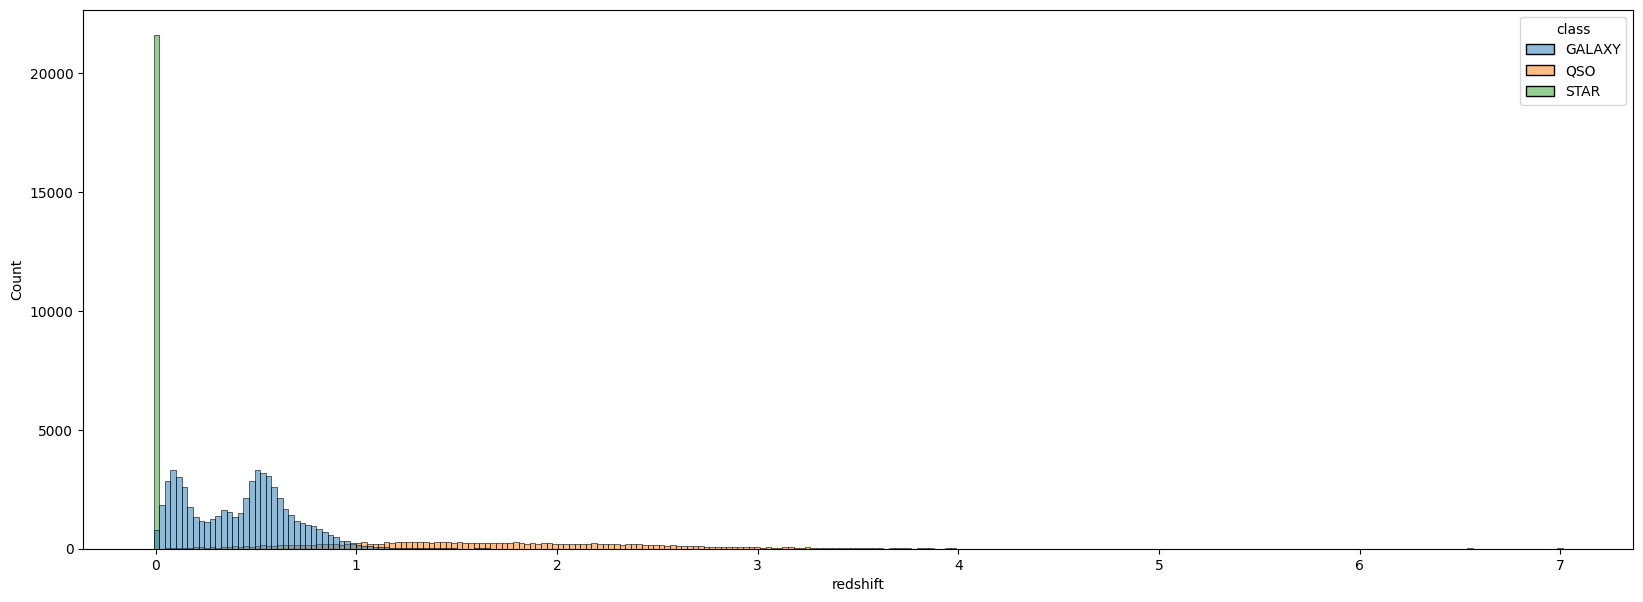

In [65]:
#Feature Distributions
import seaborn as sns
import matplotlib.pyplot as plt
plt.figure(figsize=(20,7))
sns.histplot(data=df, x='redshift', hue='class')

Stars are concentrated near redshift zero, whereas Galaxies and QSOs occupy broader ranges.
This suggests that redshift may be one of the most informative features for classification.

<Axes: xlabel='u', ylabel='Count'>

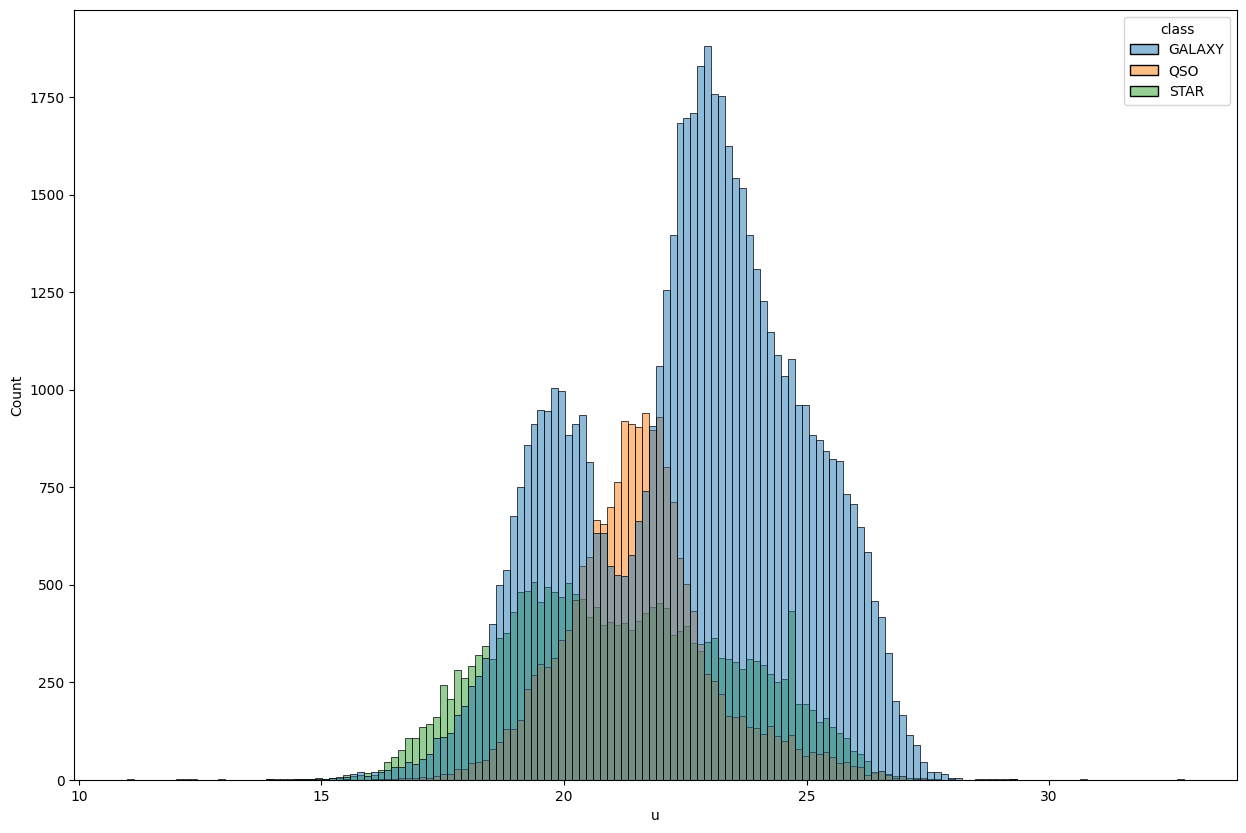

In [66]:
plt.figure(figsize=(15,10))
sns.histplot(data = df, x = 'u', hue = 'class')

<Axes: xlabel='g', ylabel='Count'>

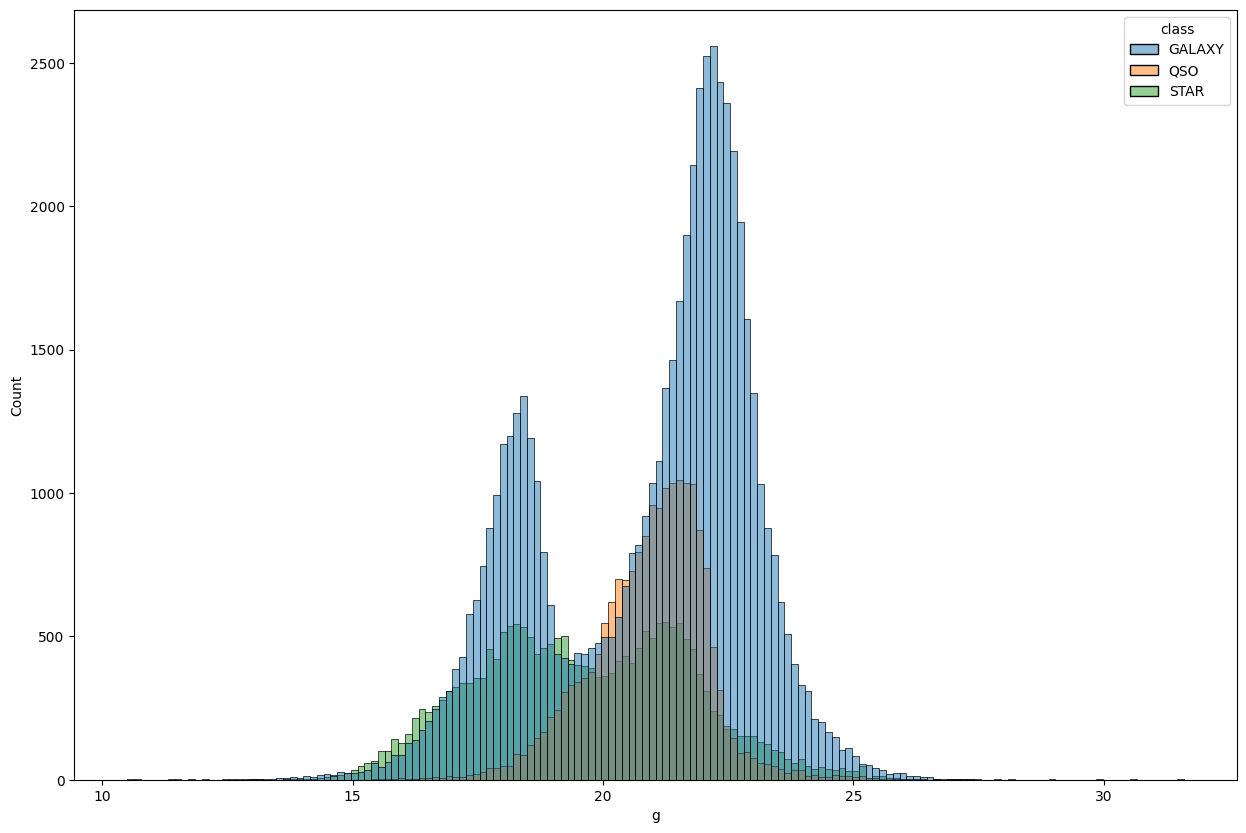

In [67]:
plt.figure(figsize=(15,10))
sns.histplot(data = df, x = 'g', hue = 'class')

<Axes: xlabel='r', ylabel='Count'>

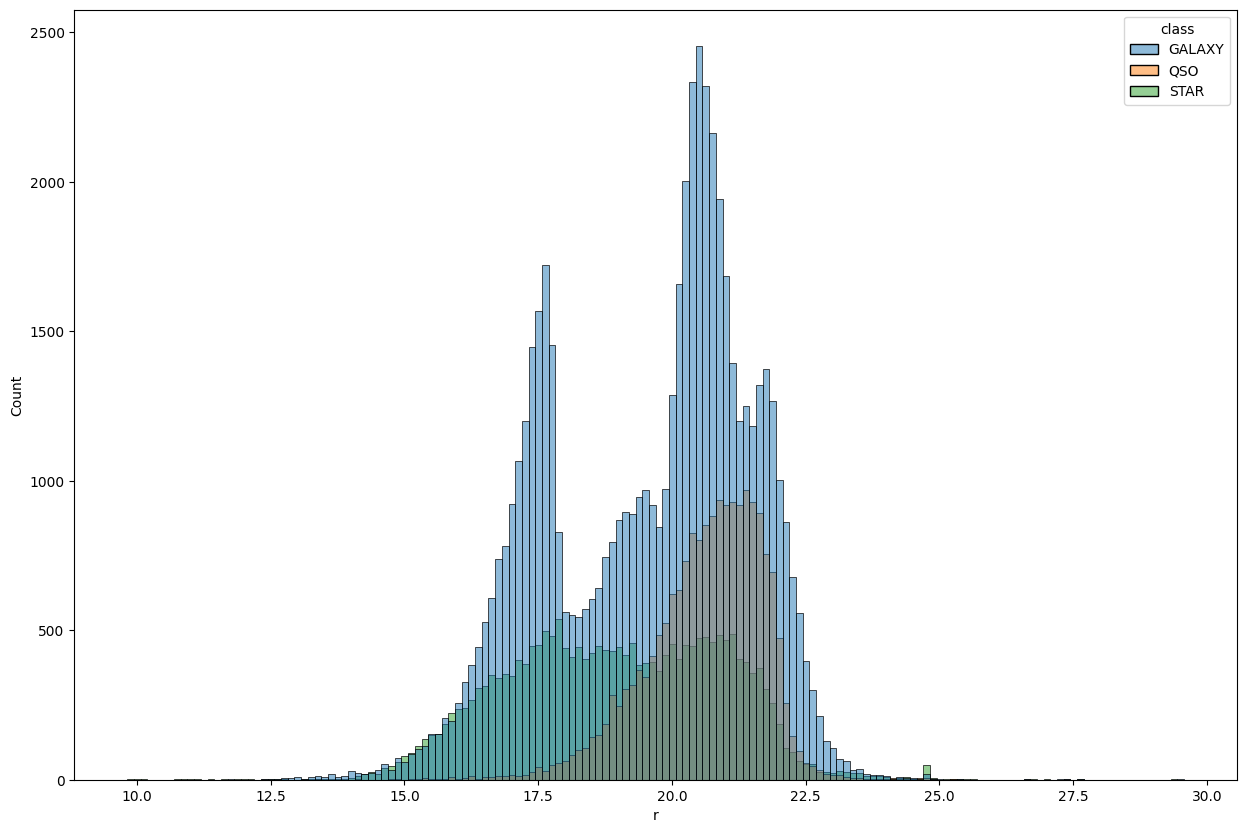

In [68]:
plt.figure(figsize=(15,10))
sns.histplot(data = df, x = 'r', hue = 'class')

<Axes: xlabel='i', ylabel='Count'>

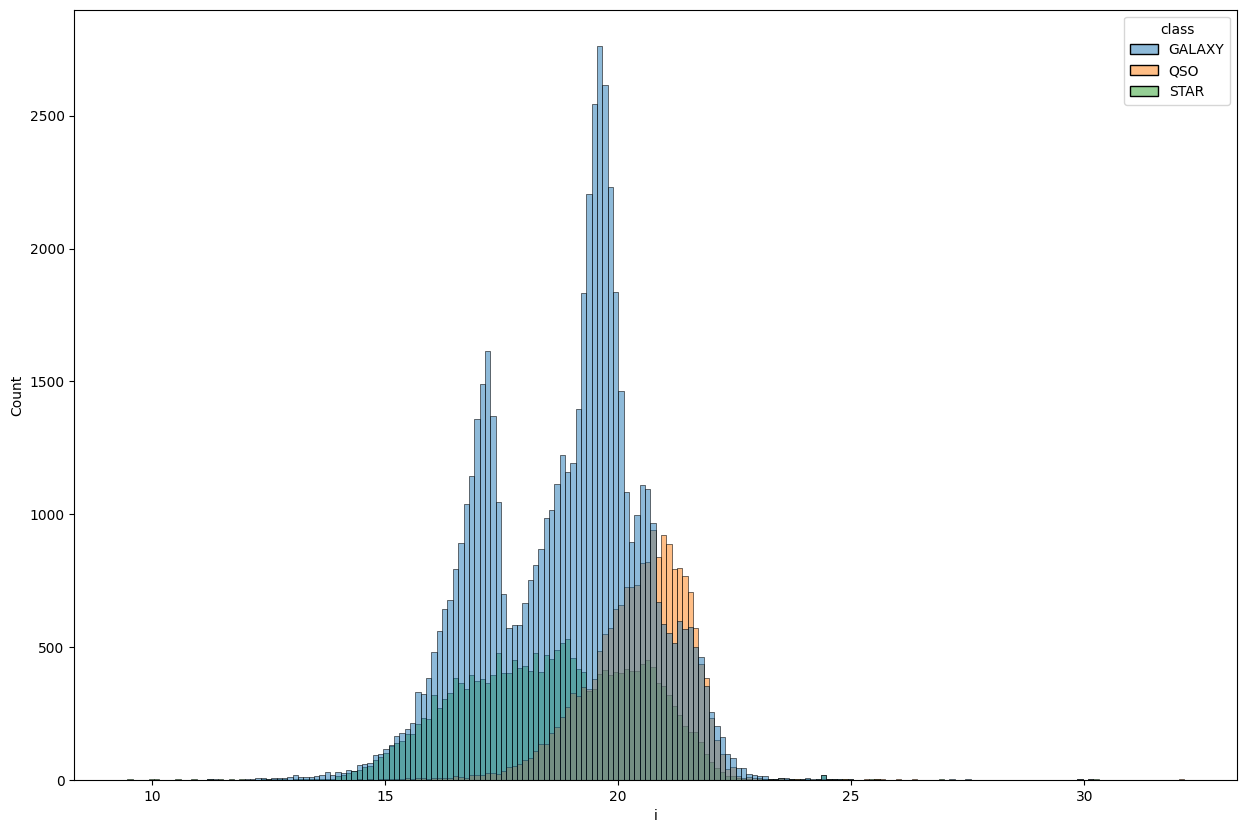

In [69]:
plt.figure(figsize=(15,10))
sns.histplot(data = df, x = 'i', hue = 'class')

<Axes: xlabel='z', ylabel='Count'>

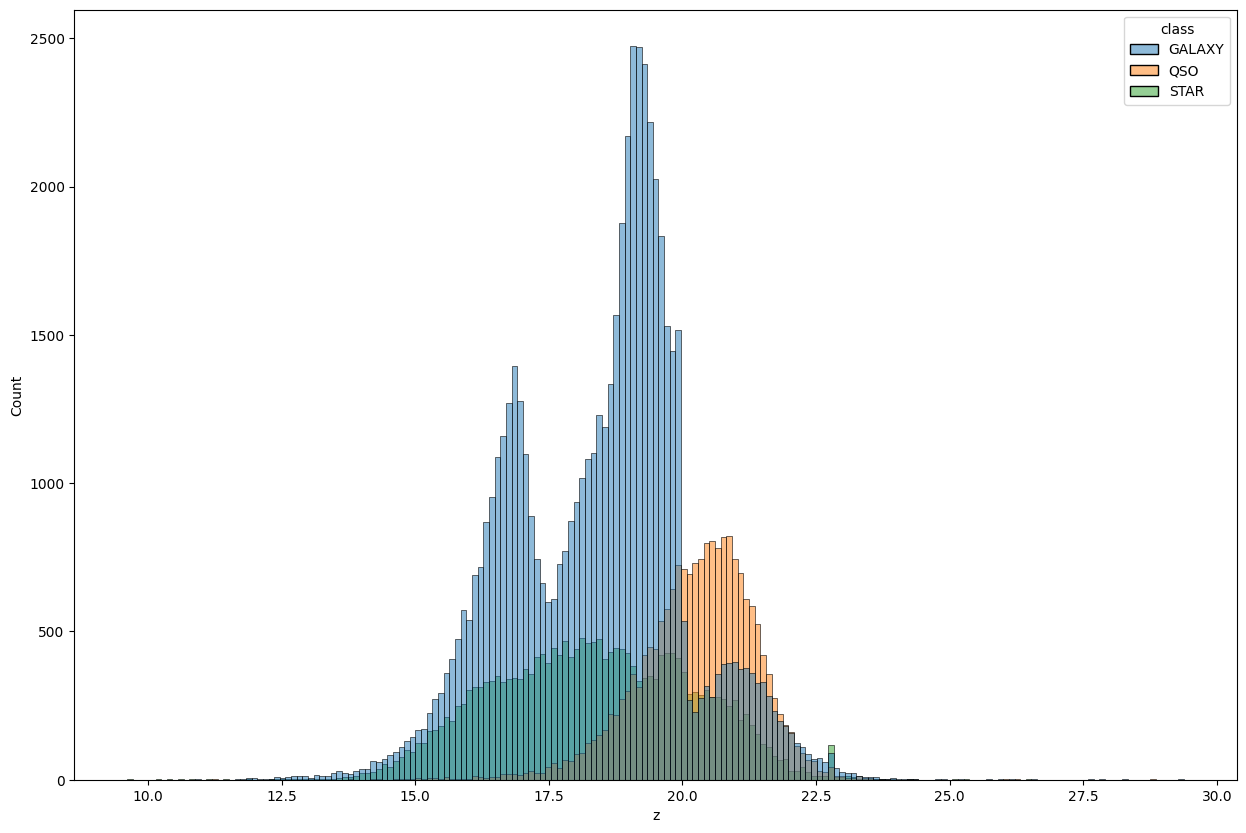

In [70]:
plt.figure(figsize=(15,10))
sns.histplot(data = df, x = 'z', hue = 'class')

*   The redshift distribution differs significantly among star, galaxy, and qso, suggesting that redshift may be a strong discriminative feature for classification.
*   The bands u, g, r, i, z are seen to have similar distribution patterns across classes. This suggests a possible correlation among these features, which can be investigated through correlation analysis.

In [71]:
cols = ['u', 'g', 'r', 'i', 'z', 'redshift']
df[cols].corr()

,u,g,r,i,z,redshift
u,1.000000,0.853350,0.728681,0.618346,0.545760,0.166816
g,0.853350,1.000000,0.932996,0.847046,0.775302,0.318910
r,0.728681,0.932996,1.000000,0.962868,0.919114,0.433237
i,0.618346,0.847046,0.962868,1.000000,0.971546,0.492381
z,0.545760,0.775302,0.919114,0.971546,1.000000,0.501060
redshift,0.166816,0.318910,0.433237,0.492381,0.501060,1.000000


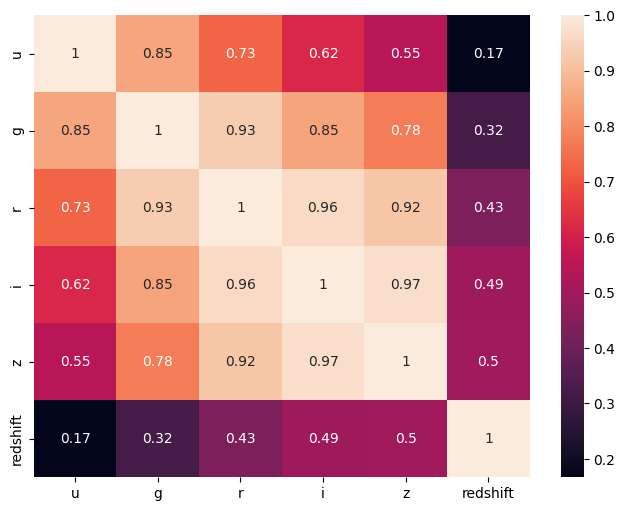

In [72]:
#Correlation Analysis
corr_matrix = df[cols].corr()

plt.figure(figsize=(8,6))
sns.heatmap(corr_matrix, annot=True)
plt.show()

Strong correlations were observed among the photometric bands, particularly between neighboring bands such as `i` and `z`.

Redshift showed comparatively weaker correlations with the photometric measurements, indicating that it may contribute additional information beyond the magnitude features.

<Axes: xlabel='delta', ylabel='alpha'>

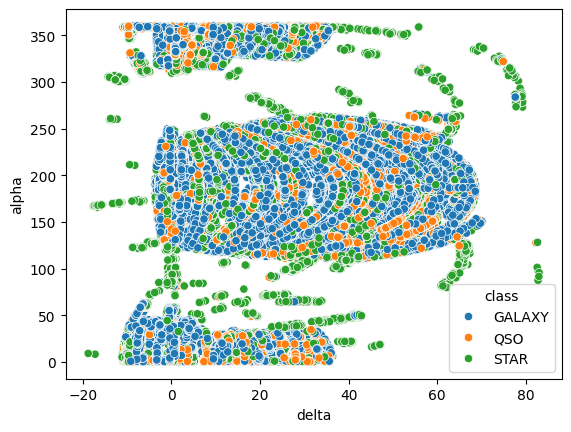

In [73]:
##Investigating alpha and delta, the sky coordinates
sns.scatterplot(data=df, x= 'delta',y='alpha', hue='class')

The plot appears to be largely mixed with no clear boundries or didtinctions, this suggests that it might not contribute much in classification

In [74]:
##Investigating the columns other than physical properties
list1 = ['run_ID','cam_col','field_ID','plate','MJD','fiber_ID']
for l in list1:
  print(l,' ',df[l].nunique())

run_ID   430
cam_col   6
field_ID   856
plate   6284
MJD   2180
fiber_ID   1000


Some of the parameters like cam_col and run_ID have very few unique values, while others like plate have many, which suggests that ones with lower no. of unique value might be useful for classification

In [75]:
#Feature Selection

import sklearn
from sklearn.model_selection import train_test_split

X = df[['alpha', 'delta', 'u', 'g', 'r', 'i', 'z','run_ID','cam_col', 'field_ID', 'redshift','plate', 'MJD', 'fiber_ID']]
y = df['class']

#We dropped 'obj_ID' and 'spec_obj_ID' since it has nothing to do with the physical properties and may introduce data specific patterns

#Train Test Split
train_X,test_X,train_y,test_y = train_test_split(X,y,test_size = 0.2,stratify = y, random_state = 1)
print(train_X.shape,'\n',test_X.shape)

(79999, 14) 
 (20000, 14)


The dataset was divided into training and testing subsets using an 80:20 ratio.
Stratified sampling was used to preserve the original class proportions in both subsets.

In [76]:
print(train_y.value_counts(normalize=True),'\n',test_y.value_counts(normalize=True))

class
GALAXY    0.594457
STAR      0.215928
QSO       0.189615
Name: proportion, dtype: float64 
 class
GALAXY    0.59445
STAR      0.21595
QSO       0.18960
Name: proportion, dtype: float64


This shows stratified sampling actaully worked

In [77]:
#Feature Scaling
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
scaler.fit(train_X)
train_X2 = scaler.transform(train_X)
test_X2 = scaler.transform(test_X)

The features in the dataset are not on the same scale. For example, redshift values are much smaller than features like plate and MJD.
Since Logistic Regression is sensitive to feature scales, we use StandardScaler to standardize the features before training the model.
The scaler was fitted on the training data and then used to transform both the training and test sets. This ensures that information from the test set is not used during training.

In [78]:
train_X2_df = pd.DataFrame(train_X2, columns= train_X.columns)
test_X2_df = pd.DataFrame(test_X2, columns = test_X.columns)
train_X2_df.describe()

,alpha,delta,u,g,r,i,z,run_ID,cam_col,field_ID,redshift,plate,MJD,fiber_ID
count,7.999900e+04,7.999900e+04,7.999900e+04,7.999900e+04,7.999900e+04,7.999900e+04,7.999900e+04,7.999900e+04,7.999900e+04,7.999900e+04,7.999900e+04,7.999900e+04,7.999900e+04,7.999900e+04
mean,-5.941988e-17,4.432066e-17,-2.779145e-16,-4.076346e-16,-2.554389e-15,1.267180e-15,1.734190e-15,-1.975333e-16,-7.913769e-17,-6.608130e-17,6.625894e-17,-1.024971e-16,6.083210e-16,-9.237171e-17
std,1.000006e+00,1.000006e+00,1.000006e+00,1.000006e+00,1.000006e+00,1.000006e+00,1.000006e+00,1.000006e+00,1.000006e+00,1.000006e+00,1.000006e+00,1.000006e+00,1.000006e+00,1.000006e+00
min,-1.840949e+00,-2.185725e+00,-4.433907e+00,-4.974682e+00,-5.300975e+00,-5.473642e+00,-5.186583e+00,-2.223406e+00,-1.582029e+00,-1.174323e+00,-8.011273e-01,-1.652573e+00,-2.204973e+00,-1.647455e+00
25%,-5.193752e-01,-9.642265e-01,-7.649297e-01,-8.173934e-01,-8.117481e-01,-7.651426e-01,-7.366105e-01,-6.593401e-01,-9.520697e-01,-6.968457e-01,-7.162302e-01,-8.852145e-01,-7.477088e-01,-8.400693e-01
50%,3.331407e-02,-2.593674e-02,4.304432e-02,2.296583e-01,2.597599e-01,1.827283e-01,1.327160e-01,-1.493405e-01,3.078493e-01,-2.664437e-01,-2.070359e-01,-5.074558e-02,1.599682e-01,-6.204300e-02
75%,5.832739e-01,8.025522e-01,7.137933e-01,7.316359e-01,7.535597e-01,7.466641e-01,6.515920e-01,4.293030e-01,9.378088e-01,3.657092e-01,1.754476e-01,7.664375e-01,6.558698e-01,7.159833e-01
max,1.888971e+00,2.996560e+00,4.751021e+00,4.527027e+00,5.351961e+00,7.427323e+00,6.007842e+00,1.871336e+00,1.567768e+00,5.402757e+00,8.825668e+00,2.509942e+00,1.848580e+00,2.018810e+00


After scaling, the features have mean approximately equal to 0 and standard deviation approximately equal to 1.

In [79]:
#Logistic(Softmax) Regression
from sklearn.linear_model import LogisticRegression
lr_classifier= LogisticRegression(random_state = 1)
lr_classifier.fit(train_X2_df,train_y)
lr_classifier.predict(test_X2_df)


array(['GALAXY', 'GALAXY', 'GALAXY', ..., 'GALAXY', 'STAR', 'GALAXY'],
      dtype=object)

In [80]:
lr_test_ac = lr_classifier.score(test_X2_df,test_y)
print(lr_test_ac)

0.95945


In [81]:
lr_train_ac  = lr_classifier.score(train_X2_df,train_y)
print(lr_train_ac)

0.9577119713996425


In [82]:
y_pred = lr_classifier.predict(test_X2_df)
lr_classifier.n_iter_

array([67], dtype=int32)

The model achieved an accuracy of approximately 95.8% on the training set and 95.9% on the test set. Since both accuracies are very close, there is no strong evidence of overfitting.
This result is significantly higher than the baseline accuracy of about 60%, which would be obtained by always predicting the majority class (galaxy in this case). Therefore, the model is able to learn meaningful patterns from the features and distinguish between stars, galaxies and QSOs.


In [83]:
#Model Evaluation

##Confusion Matrix


from sklearn.metrics import confusion_matrix
cm_array = confusion_matrix(test_y,y_pred,normalize='true')
cm_df = pd.DataFrame(cm_array)
print(cm_df)

          0         1         2
0  0.969552  0.014383  0.016065
1  0.117089  0.881857  0.001055
2  0.000000  0.000232  0.999768


In [84]:
lr_classifier.classes_

array(['GALAXY', 'QSO', 'STAR'], dtype=object)

In [85]:
##Classification Report

from sklearn.metrics import classification_report
cr_lr = classification_report(test_y,y_pred, target_names = ['Galaxy','QSO','Star'])
print(cr_lr)

              precision    recall  f1-score   support

      Galaxy       0.96      0.97      0.97     11889
         QSO       0.95      0.88      0.92      3792
        Star       0.96      1.00      0.98      4319

    accuracy                           0.96     20000
   macro avg       0.96      0.95      0.95     20000
weighted avg       0.96      0.96      0.96     20000



Around 11% of QSO's get classified as galaxies

Stars are almost perfectly classified


Stars have a recall of 1,which means all the stars were classified as stars


Galaxy has a fairly good precision,recall and f1 score


QSO has a low recall because it is confused with galaxy


This model meets almost all the project requirements except the threshold of 0.90 for recall in case of QSO(0.88)

In [86]:
#Decision Tree

from sklearn import tree
dt_classifier = tree.DecisionTreeClassifier()
dt_classifier.fit(train_X2_df,train_y)
dt_test_acc = dt_classifier.score(test_X2_df,test_y)
print(dt_test_acc)

0.96375


In [87]:
dt_train_acc = dt_classifier.score(train_X2_df,train_y)
print(dt_train_acc)

1.0


Decision Tree achieved an accuracy of 96.44% on test data and 100% on training data, this suggests there might be some overfitting. The accuracy is higher than logistic(softmax) regression

In [88]:
##Confusion Matrix
from sklearn.metrics import confusion_matrix
pred_y_dt = dt_classifier.predict(test_X2_df)
cm_dt_array = confusion_matrix(test_y, pred_y_dt, normalize = 'true')
cm_dt_df = pd.DataFrame(cm_dt_array)
print(cm_dt_df)

          0         1         2
0  0.967281  0.031374  0.001346
1  0.083861  0.915876  0.000264
2  0.003936  0.000000  0.996064


In [89]:
##Classification Report
cr_dt = classification_report(test_y,pred_y_dt, target_names = ['Galaxy','QSO','Star'])
print(cr_dt)

              precision    recall  f1-score   support

      Galaxy       0.97      0.97      0.97     11889
         QSO       0.90      0.92      0.91      3792
        Star       1.00      1.00      1.00      4319

    accuracy                           0.96     20000
   macro avg       0.96      0.96      0.96     20000
weighted avg       0.96      0.96      0.96     20000



Still 8% of QSOs got misclassified as Galaxy, this is still better than 11% for logistic regression

Stars were again almost perfectly classified and have a perfect precision, recall, f1 score of almost 1.00

The precision for QSO is lesser than what was for logistic regression suggesting that more non-QSO entities were misclassified as QSOs

This model passes all thresholds set for the per-class recall, overall accuracy and macro f1 score

In [90]:
#Random Forest

from sklearn.ensemble import RandomForestClassifier
rf_classifier = RandomForestClassifier(random_state = 1)
rf_classifier.fit(train_X2_df,train_y)
pred_y_rf = rf_classifier.predict(test_X2_df)
rf_test_acc = rf_classifier.score(test_X2_df,test_y)
print(rf_test_acc)

0.97815


In [91]:
rf_train_acc = rf_classifier.score(train_X2_df,train_y)
print(rf_train_acc)

0.999987499843748


The Random Forest model achives a test accuracy of 97.82% and train accuracy of 99.99% which is the highest so far.

In [95]:
##Confusion Matrix
from sklearn.metrics import confusion_matrix
cm_rf_array = confusion_matrix(test_y, pred_y_rf, normalize = 'true')
cm_rf_df = pd.DataFrame(cm_rf_array)
print(cm_rf_df)

          0         1         2
0  0.986206  0.010262  0.003533
1  0.070411  0.929325  0.000264
2  0.001158  0.000000  0.998842


In [96]:
##Classifcation Report
cr_rf = classification_report(test_y,pred_y_rf, target_names = ['Galaxy','QSO','Star'])
print(cr_rf)

              precision    recall  f1-score   support

      Galaxy       0.98      0.99      0.98     11889
         QSO       0.97      0.93      0.95      3792
        Star       0.99      1.00      0.99      4319

    accuracy                           0.98     20000
   macro avg       0.98      0.97      0.97     20000
weighted avg       0.98      0.98      0.98     20000



The recall for QSO increased to 0.93, indicating that 93% of actual QSOs were correctly classified, also the increase in precicion shows that lesser no. of galaxies were classified as QSOs

All the evaluation metrics are close to 1 for Stars and Galaxies

The model is well above the threshold requirements for the project

In [97]:
#PCA
from sklearn.decomposition import PCA
pca = PCA(n_components = 2)
scaler2 = StandardScaler()
scaler2.fit(X)
scaled_X = scaler2.transform(X)
pca.fit(scaled_X)
pca_X = pca.transform(scaled_X)
pca_X_df = pd.DataFrame(pca_X, columns = ['PC1','PC2'])
pca_X_df

,PC1,PC2
0,0.815556,0.319606
1,3.650872,0.512313
2,0.965698,0.201673
3,2.578468,0.085065
4,-2.548211,0.440100
...,...,...
99994,2.668284,-3.375092
99995,1.704453,-1.779120
99996,-2.059753,-0.777042
99997,0.931176,1.194635


In [98]:
pca.explained_variance_ratio_

array([0.40819903, 0.10408559])

This shows first 2 components together constitute to about 50% of the variation in data

<Axes: xlabel='PC1', ylabel='PC2'>

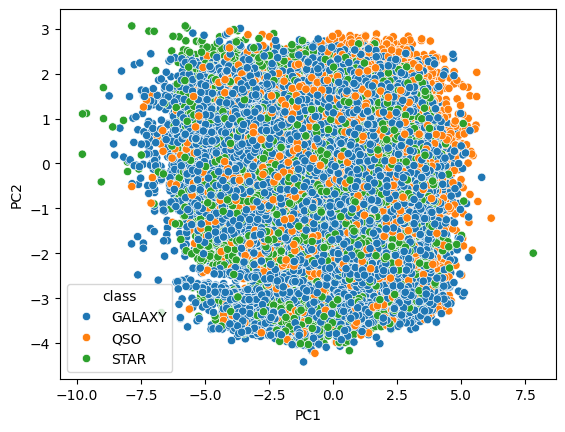

In [99]:
pca_X_df['class']=y
sns.scatterplot(data = pca_X_df , x = 'PC1', y = 'PC2', hue = 'class' )


In [100]:
#Hyperparameter Tuning

from sklearn.model_selection import GridSearchCV
rf = RandomForestClassifier(random_state= 2)
parameters = {'n_estimators': [10,50, 100],'max_depth': [5,10,15,None],'min_samples_split': [2,5, 10],'min_samples_leaf': [1,2, 4]}
classifier_gscv = GridSearchCV(rf,parameters,n_jobs = -1,cv = 5,scoring = 'accuracy')
classifier_gscv.fit(train_X,train_y)
print(classifier_gscv.best_params_)
print(classifier_gscv.best_score_)

{'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 10, 'n_estimators': 10}
0.9777622327957995


GridSearchCV selected the combination of hyperparameters that achieved the highest average cross-validation accuracy. These optimized parameters will be used to train the final Random Forest classifier.


The best cross-validation accuracy obtained was approximately 97.78%, indicating that the model generalizes well on test data.

In [101]:
#Retraining Random Forest with new best set of parameters

best_rf = RandomForestClassifier(n_estimators=10, max_depth=None, min_samples_split=10, min_samples_leaf=1, random_state=2)
best_rf.fit(train_X, train_y)
pred_y_best_rf = best_rf.predict(test_X)
rf_new_test_acc = best_rf.score(test_X,test_y)
print(rf_new_test_acc)

0.97775


In [108]:
print(best_rf.score(train_X,train_y))

0.9898873735921699


This retrained model achieves 97.78% accuracy on test data and 98.98% accuracy on training data

In [102]:
##Confusion Matrix
from sklearn.metrics import confusion_matrix
cm_best_rf_array = confusion_matrix(test_y, pred_y_best_rf, normalize = 'true')
cm_best_rf_df = pd.DataFrame(cm_best_rf_array)
print(cm_rf_df)

          0         1         2
0  0.986206  0.010262  0.003533
1  0.070411  0.929325  0.000264
2  0.001158  0.000000  0.998842


In [103]:
##Classification Report
cr_best_rf = classification_report(test_y,pred_y_best_rf, target_names = ['Galaxy','QSO','Star'])
print(cr_best_rf)

              precision    recall  f1-score   support

      Galaxy       0.98      0.99      0.98     11889
         QSO       0.96      0.93      0.95      3792
        Star       0.99      1.00      1.00      4319

    accuracy                           0.98     20000
   macro avg       0.98      0.97      0.97     20000
weighted avg       0.98      0.98      0.98     20000



This is the best report so far

The metrics for Galaxy and Star are near perfect(1.00)

All the evaluation metrics are above the threshold

In [106]:
#Feature Importance

importance_df = pd.DataFrame({'Feature': train_X.columns, 'Importance': best_rf.feature_importances_})
importance_df

,Feature,Importance
0,alpha,0.007681
1,delta,0.008323
2,u,0.048894
3,g,0.055723
4,r,0.029148
5,i,0.037869
6,z,0.110429
7,run_ID,0.004260
8,cam_col,0.001353
9,field_ID,0.004084


<Axes: xlabel='Feature', ylabel='Importance'>

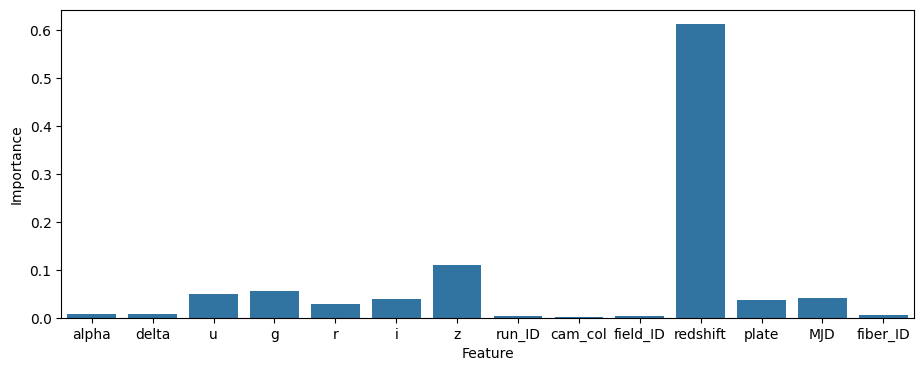

In [107]:
plt.figure(figsize=(11,4))
sns.barplot(data = importance_df, x = 'Feature', y = 'Importance')

Redshift was the single most differentiating factor inn the dataset, contributing to about 61% of the classification

u,g,r,i,z also contributed significantly ,with about 11% of z, 3-5% contribution of u,g,i on average and about 2% of r

Other features contributed little to nothing, with only about 4% of plate and MJD

**So the top 5 features were:**

* redshift  - 61%
* z - 11%
* g - 5.5%
* u - 4.8%
* MJD - 4%

In [104]:
#ROC-AUC Curves

prob_y = best_rf.predict_proba(test_X)
print(prob_y.shape)
print(prob_y[:5])
print(test_y.head)

(20000, 3)
[[1.         0.         0.        ]
 [0.98       0.         0.02      ]
 [0.93636364 0.02727273 0.03636364]
 [1.         0.         0.        ]
 [0.98571429 0.01428571 0.        ]]
<bound method NDFrame.head of 66469    GALAXY
16154    GALAXY
20664    GALAXY
85771    GALAXY
48623    GALAXY
          ...  
5694        QSO
45577    GALAXY
40807       QSO
12125      STAR
14407    GALAXY
Name: class, Length: 20000, dtype: object>


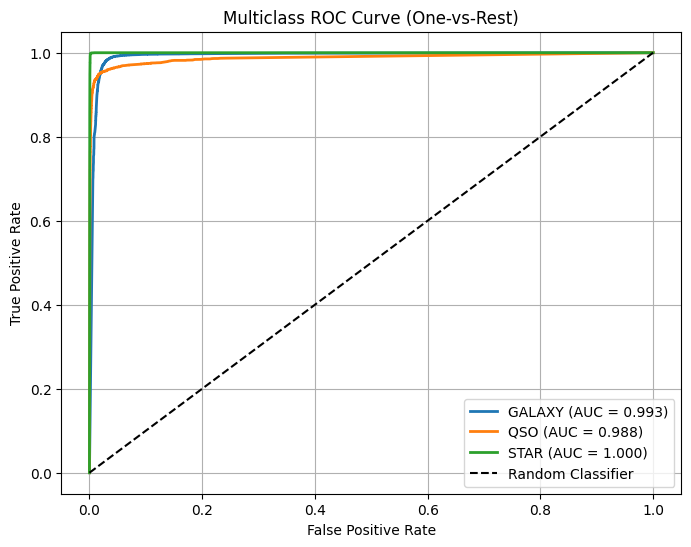

In [105]:
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc
y_test_bin = label_binarize(test_y, classes=['GALAXY', 'QSO', 'STAR'])
plt.figure(figsize=(8, 6))
classes = ['GALAXY', 'QSO', 'STAR']
for i, obj in enumerate(classes):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], prob_y[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, linewidth=2,
             label=f"{obj} (AUC = {roc_auc:.3f})")
plt.plot([0, 1], [0, 1], 'k--', label='Random Classifier')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Multiclass ROC Curve (One-vs-Rest)")
plt.legend(loc="lower right")
plt.grid(True)
plt.show()

The ROC curves for all three classes lie close to the top-left corner of the graph, indicating excellent classification performance. The high Area Under the Curve (AUC) values demonstrate that the tuned Random Forest classifier can effectively distinguish each stellar object from the remaining classes.